# Assignment 2 — Smart-Grid Energy Consumption Analysis
**40 Buildings × 500 Hours of Smart-Meter Data**

---
### Datasets
| Dataset | Role |
|---|---|
| `mainData` | Per meter per hour building + pricing + behaviour + `energyConsumKwh` |
| `weatherData` | Hourly weather per meter: temp, humidity, wind, precipitation |

---
## Task 1 — Read datasets, inspect types & structure

**Approach & reasoning:**

- Use `parse_dates` + explicit `date_format` in `read_csv` rather than `pd.to_datetime` post-hoc.  
  The timestamps are `M/D/YYYY HH:MM` (US locale). Without the format string a date like `01/02` is ambiguous (Jan 2 vs Feb 1), and pandas 3.x deprecated the old `infer_datetime_format` flag entirely.
- Call `df.info()` (schema + nulls in one shot), `df.describe()` (numeric distribution), then `df.value_counts()` for categoricals.

**Key findings from `mainData`:**
- Tariff tiers are `offPeak / midPeak / onPeak`.
- Regions are abbreviated codes: `W, MW, NE, SW, SE`.
- `solarGenerationKwh` is `0` for all night hours (9 009 non-zero rows out of 20 000).
- 4 578 rows have `energyConsumKwh == 0` (expected for low load residential overnight hours).
- Max consumption is 30.75 kWh on M023 (industrial) a notable outlier to watch in EDA.

In [49]:
import warnings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich import print
from scipy import stats
from scipy.signal import periodogram
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import holidays as hd

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='tab10', font_scale=1.1)

# ── Output folder: all figures go here, working dir stays clean ──────────────
PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def saveFig(fileName):
    """Save the current figure to the plots/ folder."""
    filePath = os.path.join(PLOTS_DIR, fileName)
    plt.savefig(filePath, dpi=150, bbox_inches='tight')
    print(f'Saved → {filePath}')

> NOTE: Honestly this can be just inspected in `Data Wrangler` don't need to make up the wheel again

In [50]:
console = Console()

# ── Read data ─────────────────────────────────────────────────────────────────
mainData = pd.read_csv(
    'data/am2buildingData.csv',
    parse_dates=['timestamp'],
    date_format='%m/%d/%Y %H:%M'
)
weatherData = pd.read_csv(
    'data/am2weatherData.csv',
    parse_dates=['timestamp'],
    date_format='%m/%d/%Y %H:%M'
)

# ── Schema & nulls ────────────────────────────────────────────────────────────
console.rule('[bold]Main data — schema & nulls')
display(mainData.info())
console.rule('[bold]Weather data — schema & nulls')
display(weatherData.info())

# ── First rows ────────────────────────────────────────────────────────────────
console.rule('[bold]Main data — first 3 rows')
display(mainData.head(3))
console.rule('[bold]Weather data — first 3 rows')
display(weatherData.head(3))

# ── Categorical distributions ─────────────────────────────────────────────────
console.rule('[bold]Categorical distributions (Main)')
catCols = ['buildingType', 'region', 'evCharger', 'tariffTier']
for col in catCols:
    console.print(f'\n[cyan]{col}[/]')
    display(mainData.drop_duplicates('meterId')[col].value_counts())

# ── Numeric summaries ─────────────────────────────────────────────────────────
console.rule('[bold]Numeric summaries')
display(mainData.describe().round(3))
display(weatherData.describe().round(3))

─────────────────────────────────────────── Main data — schema & nulls ────────────────────────────────────────────

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   meterId             20000 non-null  str           
 1   timestamp           20000 non-null  datetime64[us]
 2   region              20000 non-null  str           
 3   buildingType        20000 non-null  str           
 4   floorAreaM2         20000 non-null  int64         
 5   insulationRating    20000 non-null  float64       
 6   hvacAgeYears        20000 non-null  float64       
 7   solarCapacityKw     20000 non-null  float64       
 8   evCharger           20000 non-null  int64         
 9   tariffTier          20000 non-null  str           
 10  gridPriceUsdPerKwh  20000 non-null  float64       
 11  occupancyIndex      20000 non-null  float64       
 12  solarGenerationKwh  20000 non-null  float64       
 13  energyConsumKwh     20000 non-null  float64       
dtypes

None

────────────────────────────────────────── Weather data — schema & nulls ──────────────────────────────────────────

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    20000 non-null  datetime64[us]
 1   meterId      20000 non-null  str           
 2   tempC        20000 non-null  float64       
 3   humidityPct  20000 non-null  float64       
 4   windMs       20000 non-null  float64       
 5   precipMm     20000 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 937.6 KB


...

tariffTier

tariffTier
offPeak    40
Name: count, dtype: int64

──────────────────────────────────────────────── Numeric summaries ────────────────────────────────────────────────

,timestamp,floorAreaM2,insulationRating,hvacAgeYears,solarCapacityKw,evCharger,gridPriceUsdPerKwh,occupancyIndex,solarGenerationKwh,energyConsumKwh
count,20000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,2025-01-11 09:30:00,175.100,0.632,8.392,3.182,0.525,0.168,0.522,1.005,1.557
min,2025-01-01 00:00:00,72.000,0.391,0.000,0.000,0.000,0.098,0.050,0.000,0.000
25%,2025-01-06 04:45:00,122.750,0.513,5.240,2.142,0.000,0.134,0.414,0.000,0.183
50%,2025-01-11 09:30:00,158.000,0.618,7.905,3.026,1.000,0.155,0.553,0.000,1.237
75%,2025-01-16 14:15:00,236.250,0.711,10.189,4.424,1.000,0.211,0.676,1.712,2.121
max,2025-01-21 19:00:00,309.000,0.890,20.155,6.447,1.000,0.268,1.000,7.841,30.748
std,NaN,66.898,0.128,4.300,1.827,0.499,0.041,0.212,1.529,1.795


,timestamp,tempC,humidityPct,windMs,precipMm
count,20000,20000.000,20000.000,20000.000,20000.000
mean,2025-01-11 09:30:00,5.509,51.689,3.063,0.283
min,2025-01-01 00:00:00,-6.780,15.000,0.010,0.000
25%,2025-01-06 04:45:00,2.370,41.100,1.550,0.000
50%,2025-01-11 09:30:00,5.485,52.000,2.590,0.000
75%,2025-01-16 14:15:00,8.910,62.600,4.090,0.000
max,2025-01-21 19:00:00,17.970,95.000,18.000,6.000
std,NaN,4.564,15.033,2.072,1.007


---
## Task 2 — Calendar features: `hour`, `dayOfWeek`, `isWeekend`, `isHoliday`

**Approach & reasoning:**

- `timestamp` was already parsed as `datetime64` in Task 1 so the `.dt` accessor works directly
- For holidays we use the **`holidays`** library. `hd.country_holidays('US', years=2025)` returns a dict-like set; we use a vectorised `.isin()` lookup O(n), no loops
- `mainData` does not include an `hour` column in the raw file so we derive it here along with all other calendar features
- When printing holiday dates found in the dataset, we deduplicate on `.dt.date` (not the full timestamp) to avoid one line per hourly row

In [51]:
usHolidays = hd.country_holidays('US', years=2025)

mainData['hour']      = mainData['timestamp'].dt.hour
mainData['dayOfWeek'] = mainData['timestamp'].dt.dayofweek   # 0=Mon … 6=Sun
mainData['isWeekend'] = (mainData['dayOfWeek'] >= 5).astype(int)
mainData['isHoliday'] = mainData['timestamp'].dt.date.isin(usHolidays).astype(int)

print('Holidays found in dataset window:')
holidayDates = mainData.loc[mainData['isHoliday'] == 1, 'timestamp'].dt.date.unique()
for d in sorted(holidayDates):
    print(f'  {d}  →  {usHolidays.get(d)}')

Holidays found in dataset window:

2025-01-01  →  New Year's Day

2025-01-20  →  Martin Luther King Jr. Day

---
## Task 3 — Per-meter lag features: `lag1`, `lag24`

**Approach & reasoning:**

- **`groupby('meterId')` + `.shift()`** is mandatory. Without the groupby, the last row of M001 (hour 499) bleeds into the first row of M002 (hour 0) a silent data leakage bug.
- `lag1` = consumption 1 h ago (short-term autocorrelation)
- `lag24` = same hour yesterday (captures the daily seasonal pattern)
- NaNs for the first 1 / 24 rows of each meter are expected and correct

In [52]:
mainData = mainData.sort_values(['meterId', 'timestamp']).reset_index(drop=True)

consumptionGrp = mainData.groupby('meterId')['energyConsumKwh']

mainData['lag1']  = consumptionGrp.shift(1)
mainData['lag24'] = consumptionGrp.shift(24)

print('NaN counts (expected: 40 for lag1, 960 for lag24):')
print(mainData[['lag1', 'lag24']].isnull().sum())

print('\nLag columns for M001 (first 26 rows):')
display(
    mainData.loc[
        mainData['meterId'] == 'M001',
        ['timestamp', 'energyConsumKwh', 'lag1', 'lag24']
    ].head(26)
)

NaN counts (expected: 40 for lag1, 960 for lag24):

lag1      40
lag24    960
dtype: int64

Lag columns for M001 (first 26 rows):

,timestamp,energyConsumKwh,lag1,lag24
0,2025-01-01 00:00:00,2.7074,NaN,NaN
1,2025-01-01 01:00:00,2.5389,2.7074,NaN
2,2025-01-01 02:00:00,2.6194,2.5389,NaN
3,2025-01-01 03:00:00,2.3420,2.6194,NaN
4,2025-01-01 04:00:00,2.6295,2.3420,NaN
5,2025-01-01 05:00:00,2.2090,2.6295,NaN
6,2025-01-01 06:00:00,1.6002,2.2090,NaN
7,2025-01-01 07:00:00,1.5037,1.6002,NaN
8,2025-01-01 08:00:00,0.7454,1.5037,NaN
9,2025-01-01 09:00:00,0.1676,0.7454,NaN


---
## Task 4 — Per-meter rolling features: 24-hour mean & std

**Approach & reasoning:**

- `.shift(1).rolling(24)` rather than plain `.rolling(24)` to avoid look ahead bias the window must end at `t-1`
- `.transform()` keeps results aligned to the original DataFrame index without needing a merge

In [53]:
def laggedRolling(series, window, agg):
    """Shift-then-roll to avoid look-ahead bias."""
    shifted = series.shift(1)
    if agg == 'mean':
        return shifted.rolling(window, min_periods=window).mean()
    elif agg == 'std':
        return shifted.rolling(window, min_periods=window).std()

consumptionGrp = mainData.groupby('meterId')['energyConsumKwh']

mainData['roll24Mean'] = consumptionGrp.transform(laggedRolling, window=24, agg='mean')
mainData['roll24Std']  = consumptionGrp.transform(laggedRolling, window=24, agg='std')

print('NaN counts (expected: 960 each):')
print(mainData[['roll24Mean', 'roll24Std']].isnull().sum())

print('\nRolling columns for M001:')
display(
    mainData.loc[
        mainData['meterId'] == 'M001',
        ['timestamp', 'energyConsumKwh', 'roll24Mean', 'roll24Std']
    ].iloc[22:28]
)

NaN counts (expected: 960 each):

roll24Mean    960
roll24Std     960
dtype: int64

Rolling columns for M001:

,timestamp,energyConsumKwh,roll24Mean,roll24Std
22,2025-01-01 22:00:00,2.8484,NaN,NaN
23,2025-01-01 23:00:00,3.3381,NaN,NaN
24,2025-01-02 00:00:00,3.1059,1.909492,0.914866
25,2025-01-02 01:00:00,2.9413,1.926096,0.933405
26,2025-01-02 02:00:00,2.5634,1.942863,0.948386
27,2025-01-02 03:00:00,2.9030,1.940529,0.946716


---
## Task 5 — Build master time-series DataFrame

**Approach & reasoning:**

- Inner merge on `['meterId', 'timestamp']` any row count mismatch after the join signals a real data issue
- `timestamp` becomes the **DatetimeIndex** via `set_index`. All of Tasks 10 → 12 expect a DatetimeIndex
- `meterId` stays as a regular column for easy single meter slicing

In [54]:
weatherExtra = weatherData.drop(
    columns=[c for c in weatherData.columns
             if c in mainData.columns and c not in ('meterId', 'timestamp')]
)

masterDf = (
    pd.merge(mainData, weatherExtra, on=['meterId', 'timestamp'], how='inner')
    .set_index('timestamp')
    .sort_index()
)

print(f'Shape : {masterDf.shape}  (expected 20 000 rows)')
print(f'Index : {masterDf.index.dtype}  |  {masterDf.index.min()} → {masterDf.index.max()}')

m001Idx = pd.DatetimeIndex(masterDf[masterDf['meterId'] == 'M001'].index)
print(f'Inferred freq for M001 : {pd.infer_freq(m001Idx)}')

print('\nFinal schema:')
masterDf.info()
display(masterDf.head(3))

Shape : (20000, 25)  (expected 20 000 rows)

Index : datetime64  |  2025-01-01 00:00:00 → 2025-01-21 19:00:00

Inferred freq for M001 : h

Final schema:

<class 'pandas.DataFrame'>
DatetimeIndex: 20000 entries, 2025-01-01 00:00:00 to 2025-01-21 19:00:00
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   meterId             20000 non-null  str    
 1   region              20000 non-null  str    
 2   buildingType        20000 non-null  str    
 3   floorAreaM2         20000 non-null  int64  
 4   insulationRating    20000 non-null  float64
 5   hvacAgeYears        20000 non-null  float64
 6   solarCapacityKw     20000 non-null  float64
 7   evCharger           20000 non-null  int64  
 8   tariffTier          20000 non-null  str    
 9   gridPriceUsdPerKwh  20000 non-null  float64
 10  occupancyIndex      20000 non-null  float64
 11  solarGenerationKwh  20000 non-null  float64
 12  energyConsumKwh     20000 non-null  float64
 13  hour                20000 non-null  int32  
 14  dayOfWeek           20000 non-null  int32  
 15  isWeekend           20000 non

,meterId,region,buildingType,floorAreaM2,insulationRating,hvacAgeYears,solarCapacityKw,evCharger,tariffTier,gridPriceUsdPerKwh,...,isWeekend,isHoliday,lag1,lag24,roll24Mean,roll24Std,tempC,humidityPct,windMs,precipMm
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-01,M001,W,commercial,113,0.709966,16.486924,2.762723,1,offPeak,0.1330,...,0,1,NaN,NaN,NaN,NaN,0.41,44.0,2.73,0.0
2025-01-01,M027,SW,residential,94,0.775267,11.853957,0.000000,1,offPeak,0.1233,...,0,1,NaN,NaN,NaN,NaN,6.34,28.0,1.08,0.0
2025-01-01,M028,SW,residential,237,0.703531,4.888291,2.902563,1,offPeak,0.1203,...,0,1,NaN,NaN,NaN,NaN,5.59,37.7,7.88,0.0


---
## Task 6 — Select one residential meter: descriptive statistics

**Meter selection:** pick the residential meter with highest standard deviation in consumption.

In [55]:
resMeters = (
    masterDf[masterDf['buildingType'] == 'residential']
    .groupby('meterId')['energyConsumKwh']
    .std()
    .sort_values(ascending=False)
)
METER = resMeters.index[0]
print(f'Selected meter : {METER}  (std = {resMeters[METER]:.3f} kWh)')

mDf = masterDf[masterDf['meterId'] == METER].copy()

print('\n--- Building profile ---')
staticCols = [
    'buildingType', 'region', 'floorAreaM2', 'insulationRating',
    'hvacAgeYears', 'solarGenerationKwh', 'evCharger'
]
print(mDf[staticCols].iloc[0].to_string())

print('\n--- Consumption descriptive stats ---')
consumptionStats = mDf['energyConsumKwh'].describe(percentiles=[.05, .25, .5, .75, .95])
consumptionStats['CV (std/mean)'] = consumptionStats['std'] / consumptionStats['mean']
print(consumptionStats.round(3))

print('\n--- Weather descriptive stats ---')
display(mDf[['tempC', 'humidityPct', 'windMs', 'precipMm']].describe().round(2))

print('\n--- Consumption by hour (mean ± std) ---')
display(
    mDf.groupby('hour')['energyConsumKwh']
    .agg(['mean', 'std', 'min', 'max'])
    .round(3)
)

Selected meter : M002  (std = 1.073 kWh)

--- Building profile ---

buildingType          residential
region                         MW
floorAreaM2                   309
insulationRating         0.514178
hvacAgeYears             20.15545
solarGenerationKwh            0.0
evCharger                       0

--- Consumption descriptive stats ---

count            500.000
mean               1.283
std                1.073
min                0.000
5%                 0.000
25%                0.000
50%                1.764
75%                2.141
95%                2.480
max                8.038
CV (std/mean)      0.836
Name: energyConsumKwh, dtype: float64

--- Weather descriptive stats ---

,tempC,humidityPct,windMs,precipMm
count,500.00,500.00,500.00,500.00
mean,1.01,60.10,2.96,0.25
std,3.21,9.40,1.96,0.97
min,-6.27,32.20,0.12,0.00
25%,-1.56,53.08,1.53,0.00
50%,1.23,60.75,2.60,0.00
75%,3.50,66.95,3.92,0.00
max,9.77,83.30,12.07,6.00


--- Consumption by hour (mean ± std) ---

,mean,std,min,max
hour,,,,
0,2.116,0.473,1.582,3.883
1,2.009,0.222,1.462,2.391
2,1.949,0.194,1.568,2.217
3,2.112,0.786,1.491,5.397
4,2.020,0.188,1.694,2.414
5,2.031,0.170,1.684,2.409
6,2.113,0.186,1.694,2.350
7,1.152,0.232,0.781,1.724
8,0.291,0.256,0.000,0.889


---
## Task 7 — Visualisation: consumption profile & weather relationships

| Plot | Library | What it reveals |
|---|---|---|
| Time-series line | matplotlib | Full consumption trajectory over 500 h |
| Boxplot by hour | seaborn | Diurnal shape + spread |
| Heatmap (hour × weekday) | seaborn | Two-way calendar pattern |
| Scatter + regression | seaborn `regplot` | Consumption vs temperature |
| KDE | seaborn | Overall distribution shape |
| Bar (solar vs consumption) | matplotlib | Solar offset magnitude by hour |

Saved → plots\visualEda.png

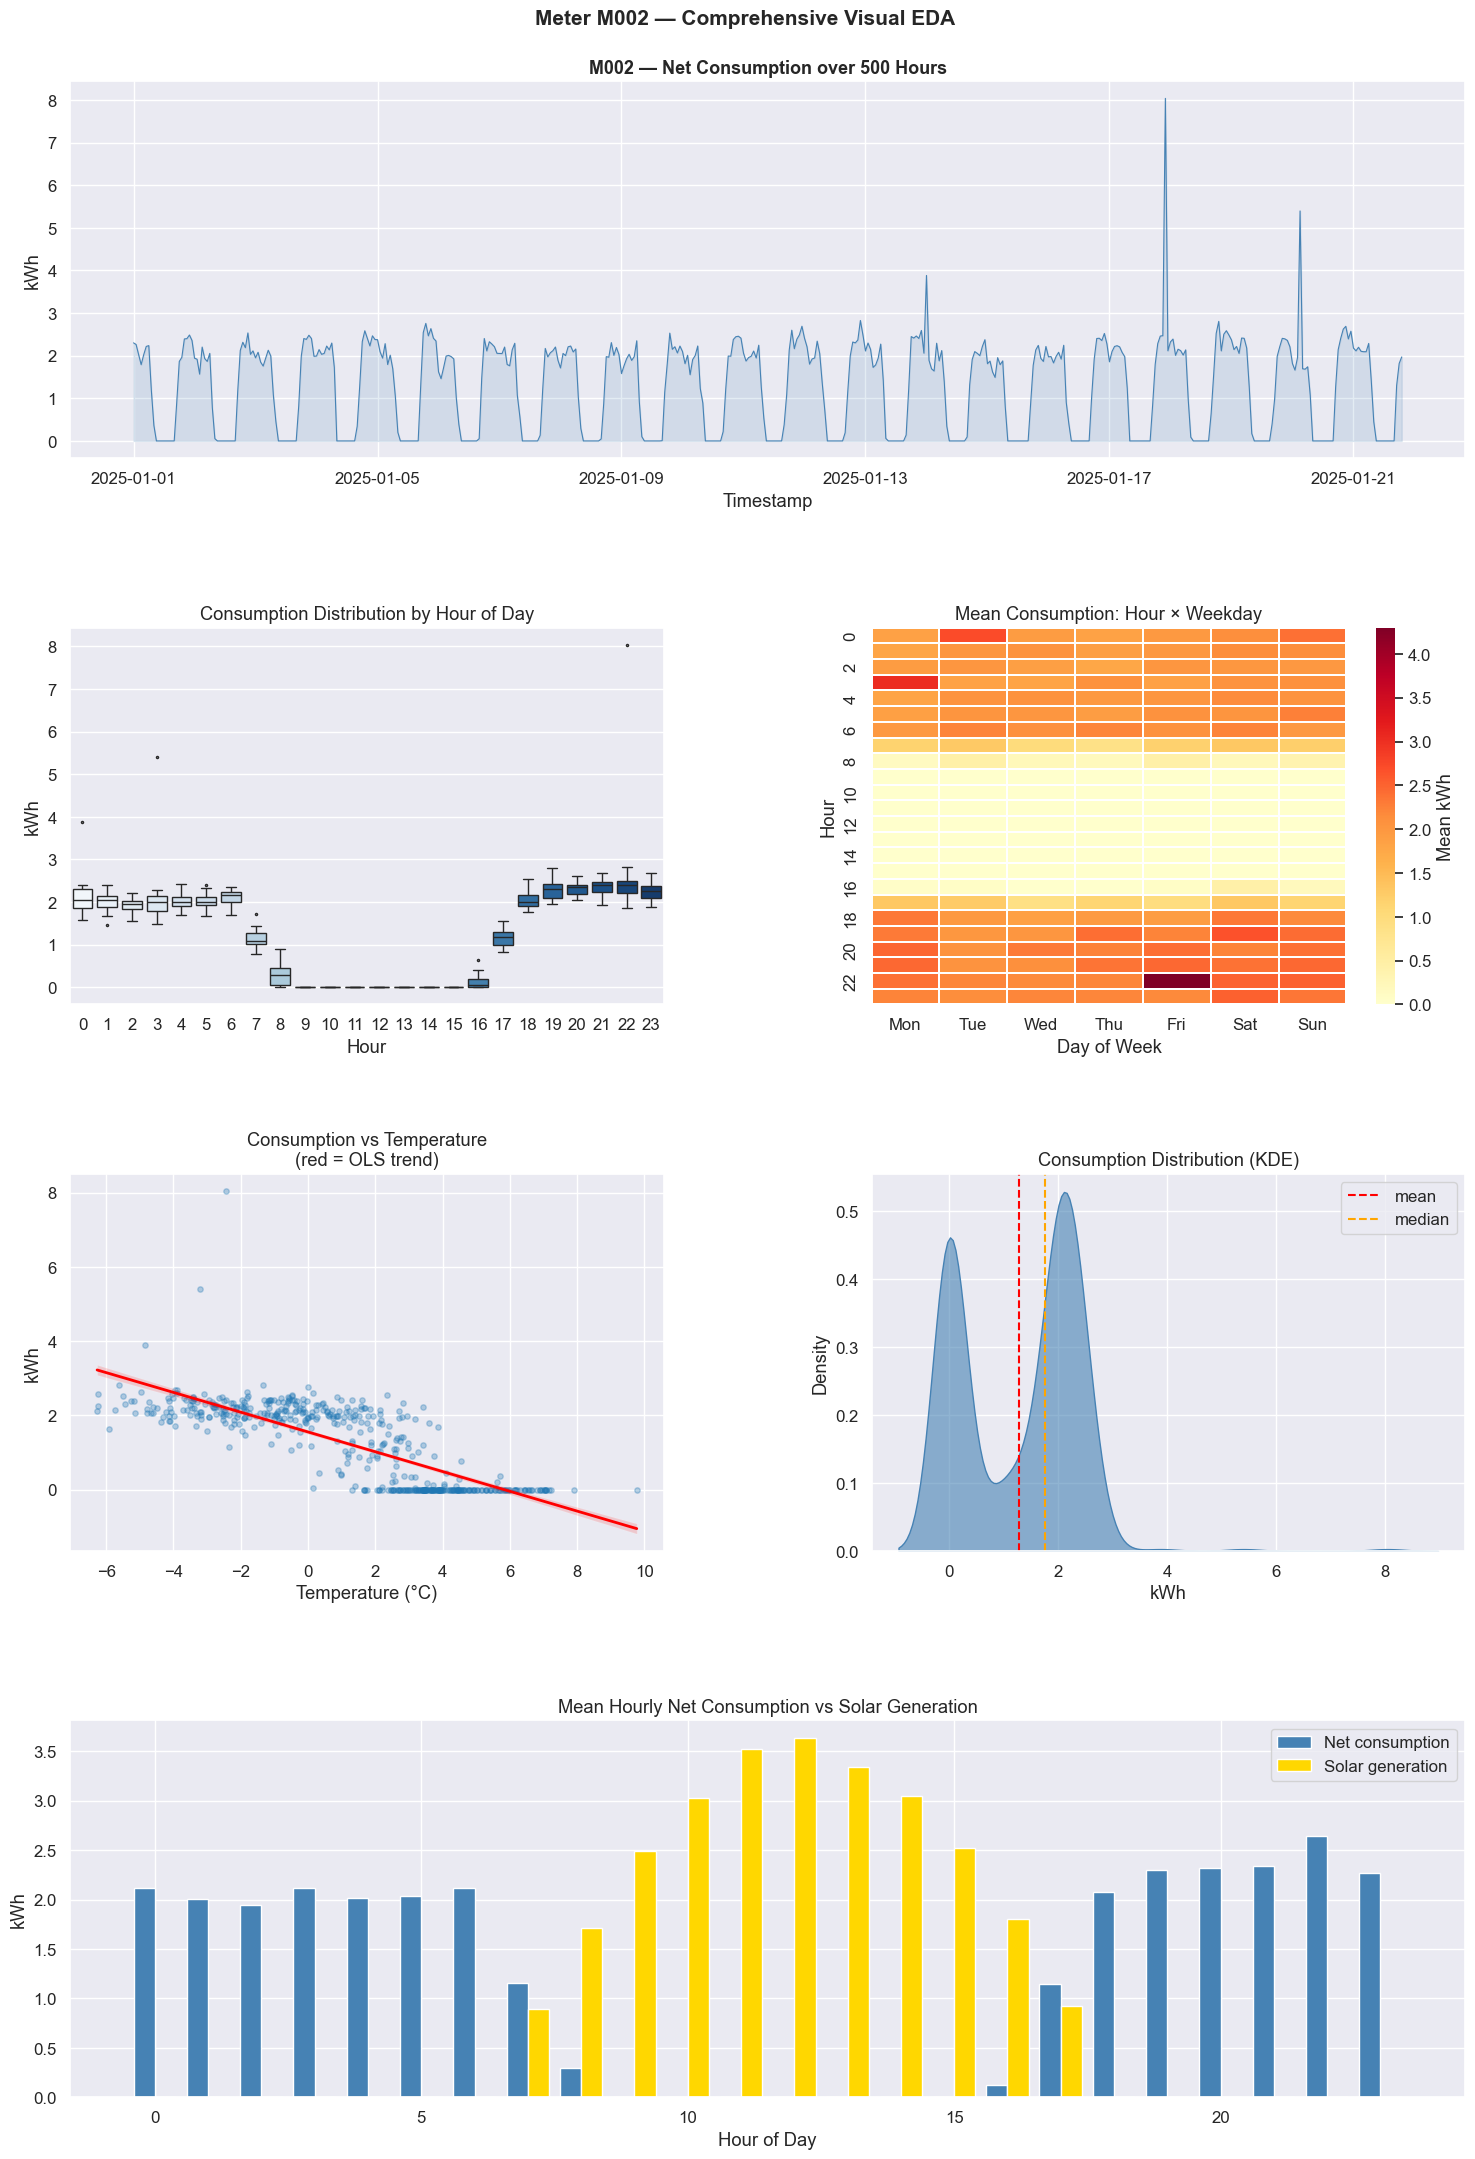

In [56]:
fig = plt.figure(figsize=(18, 24))
fig.subplots_adjust(top=0.95)
gs  = fig.add_gridspec(4, 2, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(mDf.index, mDf['energyConsumKwh'], lw=0.8, color='steelblue')
ax1.fill_between(mDf.index, mDf['energyConsumKwh'], alpha=0.15, color='steelblue')
ax1.set_title(f'{METER} — Net Consumption over 500 Hours', fontsize=13, fontweight='bold')
ax1.set_xlabel('Timestamp'); ax1.set_ylabel('kWh')

ax2 = fig.add_subplot(gs[1, 0])
sns.boxplot(
    data=mDf, x='hour', y='energyConsumKwh',
    palette='Blues', flierprops=dict(marker='.', ms=3), ax=ax2
)
ax2.set_title('Consumption Distribution by Hour of Day')
ax2.set_xlabel('Hour'); ax2.set_ylabel('kWh')

ax3 = fig.add_subplot(gs[1, 1])
heatmapPivot = (
    mDf.groupby(['hour', 'dayOfWeek'])['energyConsumKwh']
    .mean()
    .unstack('dayOfWeek')
)
heatmapPivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.heatmap(
    heatmapPivot, cmap='YlOrRd', linewidths=0.3,
    cbar_kws={'label': 'Mean kWh'}, ax=ax3
)
ax3.set_title('Mean Consumption: Hour × Weekday')
ax3.set_xlabel('Day of Week'); ax3.set_ylabel('Hour')

ax4 = fig.add_subplot(gs[2, 0])
sns.regplot(
    data=mDf, x='tempC', y='energyConsumKwh',
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'red', 'lw': 2}, ax=ax4
)
ax4.set_title('Consumption vs Temperature\n(red = OLS trend)')
ax4.set_xlabel('Temperature (°C)'); ax4.set_ylabel('kWh')

ax5 = fig.add_subplot(gs[2, 1])
sns.kdeplot(data=mDf, x='energyConsumKwh', fill=True, color='steelblue', alpha=0.6, ax=ax5)
ax5.axvline(mDf['energyConsumKwh'].mean(),   color='red',    ls='--', label='mean')
ax5.axvline(mDf['energyConsumKwh'].median(), color='orange', ls='--', label='median')
ax5.set_title('Consumption Distribution (KDE)')
ax5.set_xlabel('kWh'); ax5.legend()

ax6 = fig.add_subplot(gs[3, :])
hourlyMeans = mDf.groupby('hour')[['energyConsumKwh', 'solarGenerationKwh']].mean()
xPos = hourlyMeans.index
barWidth = 0.4
ax6.bar(xPos - barWidth/2, hourlyMeans['energyConsumKwh'],    barWidth, label='Net consumption', color='steelblue')
ax6.bar(xPos + barWidth/2, hourlyMeans['solarGenerationKwh'], barWidth, label='Solar generation', color='gold')
ax6.set_title('Mean Hourly Net Consumption vs Solar Generation')
ax6.set_xlabel('Hour of Day'); ax6.set_ylabel('kWh'); ax6.legend()

plt.suptitle(f'Meter {METER} — Comprehensive Visual EDA', fontsize=15, fontweight='bold')
saveFig('visualEda.png')
plt.show()

---
## Task 8 — User behaviour: weekend & holiday effect on consumption

- **Mann-Whitney U** instead of t-test: consumption is right skewed so the non parametric test is more appropriate
- **Cohen's d** as effect size with 500 observations a t-test almost always rejects, effect size tells us whether the difference is practically meaningful

Saved → plots\behaviourAnalysis.png

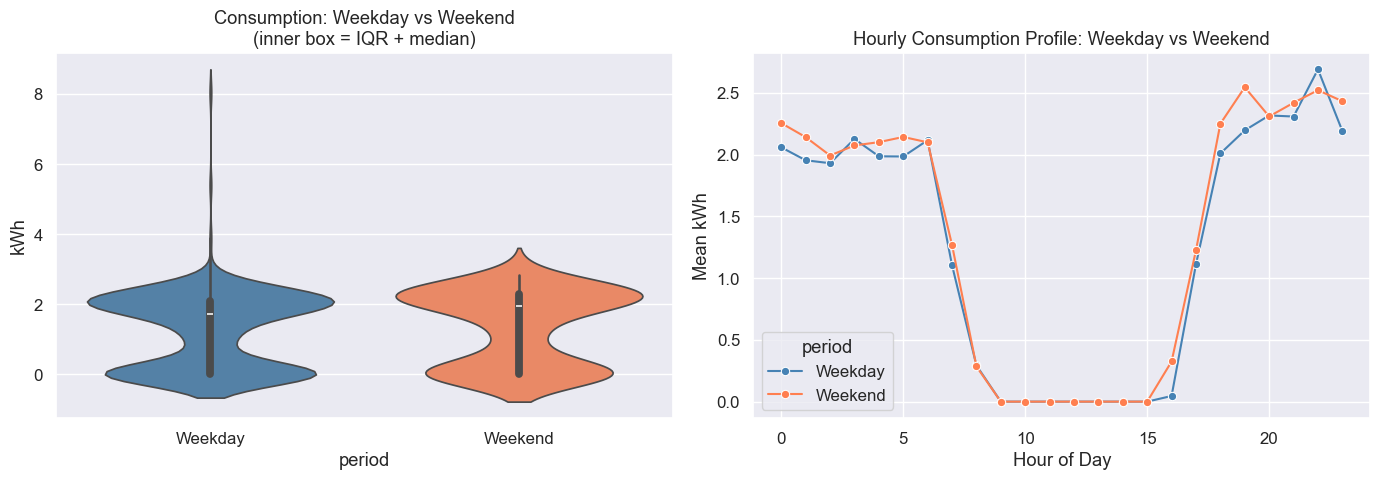

=== Weekend Effect ===

Weekday mean : 1.256 kWh   std: 1.080

Weekend mean : 1.350 kWh   std: 1.055

Mann-Whitney U p-value : 0.0365  (significant)

Cohen's d (effect size) : -0.0883  (small)

Holiday hours in window : 48

Holiday mean : 1.331 kWh  vs  Non-holiday : 1.278 kWh

In [57]:
mDf['period'] = mDf['isWeekend'].map({0: 'Weekday', 1: 'Weekend'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=mDf, x='period', y='energyConsumKwh',
    palette=['steelblue', 'coral'], inner='box', ax=axes[0]
)
axes[0].set_title('Consumption: Weekday vs Weekend\n(inner box = IQR + median)')
axes[0].set_ylabel('kWh')

hourlyPeriod = mDf.groupby(['hour', 'period'])['energyConsumKwh'].mean().reset_index()
sns.lineplot(
    data=hourlyPeriod, x='hour', y='energyConsumKwh',
    hue='period', palette=['steelblue', 'coral'], marker='o', ax=axes[1]
)
axes[1].set_title('Hourly Consumption Profile: Weekday vs Weekend')
axes[1].set_xlabel('Hour of Day'); axes[1].set_ylabel('Mean kWh')

plt.tight_layout()
saveFig('behaviourAnalysis.png')
plt.show()

weekdaySeries = mDf.loc[mDf['isWeekend'] == 0, 'energyConsumKwh']
weekendSeries = mDf.loc[mDf['isWeekend'] == 1, 'energyConsumKwh']

uStat, pVal = stats.mannwhitneyu(weekdaySeries, weekendSeries, alternative='two-sided')
cohensD     = ((weekdaySeries.mean() - weekendSeries.mean()) /
               np.sqrt((weekdaySeries.std()**2 + weekendSeries.std()**2) / 2))
effectLabel = 'small' if abs(cohensD) < 0.2 else 'medium' if abs(cohensD) < 0.5 else 'large'

print('=== Weekend Effect ===')
print(f'Weekday mean : {weekdaySeries.mean():.3f} kWh   std: {weekdaySeries.std():.3f}')
print(f'Weekend mean : {weekendSeries.mean():.3f} kWh   std: {weekendSeries.std():.3f}')
print(f'Mann-Whitney U p-value : {pVal:.4f}  ({"significant" if pVal < 0.05 else "not significant"})')
print(f"Cohen's d (effect size) : {cohensD:.4f}  ({effectLabel})")

holidaySeries    = mDf.loc[mDf['isHoliday'] == 1, 'energyConsumKwh']
nonHolidaySeries = mDf.loc[mDf['isHoliday'] == 0, 'energyConsumKwh']
print(f'\nHoliday hours in window : {len(holidaySeries)}')
if len(holidaySeries) > 0:
    print(f'Holiday mean : {holidaySeries.mean():.3f} kWh  vs  Non-holiday : {nonHolidaySeries.mean():.3f} kWh')

> NOTE: Weekend mean slightly higher (1.35 vs 1.26 kWh) but Cohen's d = -0.09 which is negligible.
> Statistically significant (p=0.04) only due to large sample size, not a real effect.
> M002 behavior is time of day driven, not weekday/holiday driven, occupant is home
> at night regardless of the day

---
## Task 9 — Price sensitivity & tariff tier analysis

Saved → plots\priceAnalysis.png

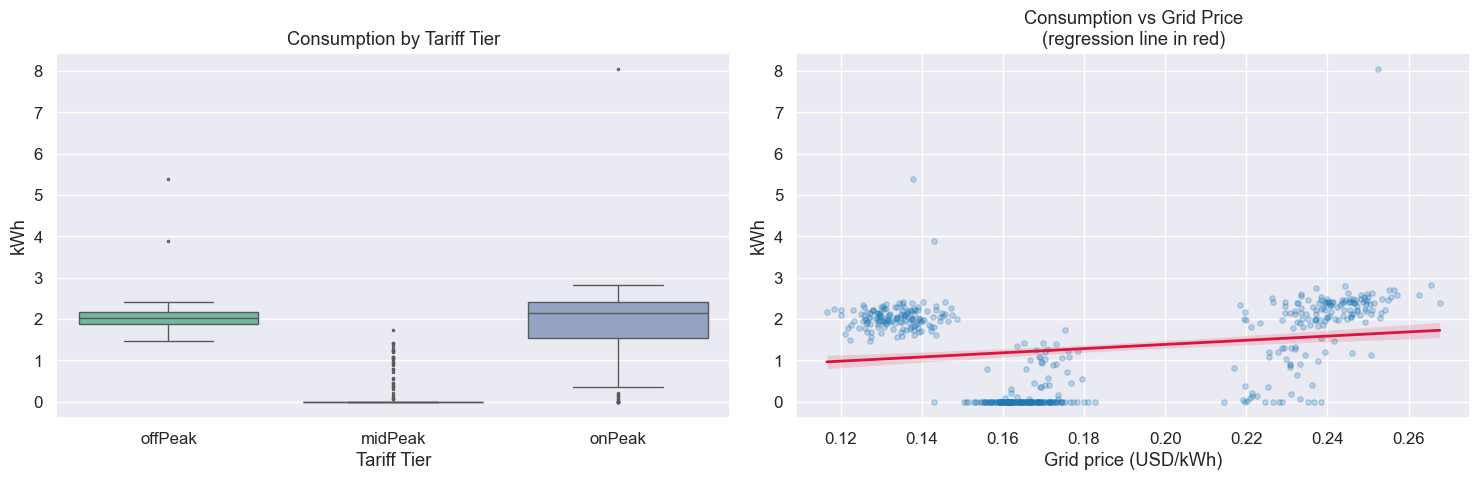

Mean consumption by tariff tier:

tariffTier
offPeak    2.050
midPeak    0.160
onPeak     1.889
Name: energyConsumKwh, dtype: float64

Pearson r (price vs consumption) = 0.2057   p = 0.0000

Interpretation: positive r → price and consumption move together (confounded by time of day: peaks drive both price
and demand).

tariffTier
midPeak    189
onPeak     164
offPeak    147
Name: count, dtype: int64

min  max  nunique
tariffTier                   
midPeak       7   15        9
offPeak       0    6        7
onPeak       16   23        8

In [58]:
tierOrder = ['offPeak', 'midPeak', 'onPeak']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=mDf, x='tariffTier', y='energyConsumKwh',
    order=tierOrder, palette='Set2',
    flierprops=dict(marker='.', ms=3), ax=axes[0]
)
axes[0].set_title('Consumption by Tariff Tier')
axes[0].set_xlabel('Tariff Tier'); axes[0].set_ylabel('kWh')

sns.regplot(
    data=mDf, x='gridPriceUsdPerKwh', y='energyConsumKwh',
    scatter_kws={'alpha': 0.25, 's': 15},
    line_kws={'color': 'crimson', 'lw': 2},
    ax=axes[1]
)
axes[1].set_title('Consumption vs Grid Price\n(regression line in red)')
axes[1].set_xlabel('Grid price (USD/kWh)'); axes[1].set_ylabel('kWh')

plt.tight_layout()
saveFig('priceAnalysis.png')
plt.show()

print('Mean consumption by tariff tier:')
print(mDf.groupby('tariffTier')['energyConsumKwh'].mean().reindex(tierOrder).round(3))

pearsonR, pearsonP = stats.pearsonr(mDf['gridPriceUsdPerKwh'], mDf['energyConsumKwh'])
print(f'\nPearson r (price vs consumption) = {pearsonR:.4f}   p = {pearsonP:.4f}')
print('Interpretation: positive r → price and consumption move together '
      '(confounded by time of day: peaks drive both price and demand).')

# How many rows per tier?
print(mDf['tariffTier'].value_counts())

# What hours does each tier cover?
print(mDf.groupby('tariffTier')['hour'].agg(['min', 'max', 'nunique']))

> NOTE: midPeak mean (0.160 kWh) is misleadingly low not a price response
> midPeak covers hours 7–15, which overlaps with M002's daytime idle window
> (zero consumption 9–15)
> This is a behavioral quirk of this meter, not evidence of price elasticity

---
## Task 10 — Stationarity & periodicity tests

**ADF:** H₀ = unit root (non-stationary). Reject → stationary
**KPSS:** H₀ = stationary. Fail to reject → stationary  
Using both together disambiguates

**On the KPSS `InterpolationWarning`:**  
The warning fires when the test statistic falls *below* the smallest entry in statsmodels' look-up table. The library caps the reported p-value at `0.1` the actual p-value is strictly **greater than 0.1**, meaning the evidence for stationarity is even stronger than the table can express. We:
1. Pre-compute `nlags` with the Schwert (1989) rule `int(12 × (n/100)^0.25)` so the value is explicit and documented
2. Suppress the warning with `warnings.filterwarnings` and print a clear explanation in the output instead

=== ADF Test ===

Statistic : -12.8144

p-value   : 0.0000

Verdict   : Stationary (reject H0)

=== KPSS Test ===

...

p-value    : 0.1000  ← floor; actual p > 0.1 (stat below table minimum — series comfortably stationary)

Verdict    : Stationary (fail to reject H0)

=== Combined interpretation ===

Both tests agree → series is STATIONARY. No differencing required

Saved → plots\acfPacf.png

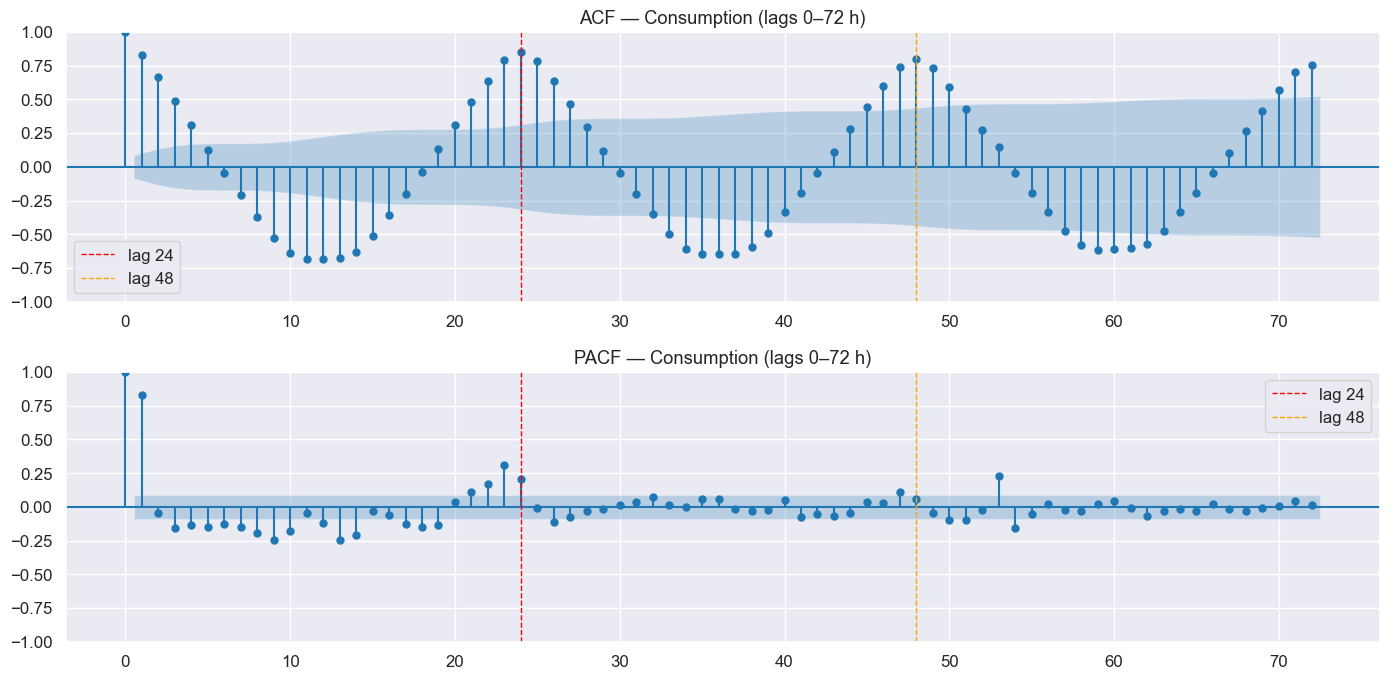

Saved → plots\periodogram.png

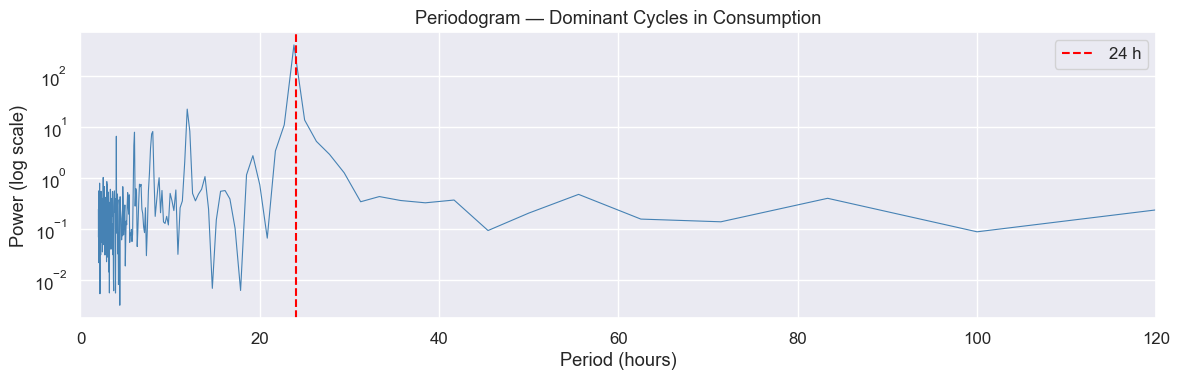

Dominant period detected : 23.8 hours

In [59]:
consumptionSeries = mDf['energyConsumKwh'].dropna()

# ── ADF test ─────────────────────────────────────────────────────────────────
adfResult = adfuller(consumptionSeries, autolag='AIC')
print('=== ADF Test ===')
print(f'  Statistic : {adfResult[0]:.4f}')
print(f'  p-value   : {adfResult[1]:.4f}')
print(f'  Verdict   : {"Stationary (reject H0)" if adfResult[1] < 0.05 else "Non-stationary (fail to reject H0)"}')

# ── KPSS test ────────────────────────────────────────────────────────────────
# nlags via Schwert (1989): int(12 * (n/100)^0.25)
# When the statistic is below the table's lower bound, statsmodels caps p at 0.1
# and raises InterpolationWarning. This means the actual p > 0.1 — series is
# even more stationary than the table can express. Suppress + explain.
kpssNlags = int(12 * (len(consumptionSeries) / 100) ** 0.25)

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='.*outside of the range.*')
    kpssResult = kpss(consumptionSeries, regression='c', nlags=kpssNlags)

print('\n=== KPSS Test ===')
print(f'  nlags used : {kpssNlags}  (Schwert 1989 rule)')
print(f'  Statistic  : {kpssResult[0]:.4f}')
pNote = '  ← floor; actual p > 0.1 (stat below table minimum — series comfortably stationary)' if kpssResult[1] >= 0.1 else ''
print(f'  p-value    : {kpssResult[1]:.4f}{pNote}')
print(f'  Verdict    : {"Non-stationary (reject H0)" if kpssResult[1] < 0.05 else "Stationary (fail to reject H0)"}')

print('\n=== Combined interpretation ===')
adfStationary  = adfResult[1] < 0.05
kpssStationary = kpssResult[1] >= 0.05
if adfStationary and kpssStationary:
    print('  Both tests agree → series is STATIONARY. No differencing required')
elif not adfStationary and not kpssStationary:
    print('  Both tests agree → NON-STATIONARY. Apply differencing (Task 12)')
elif adfStationary and not kpssStationary:
    print('  Conflicting → possibly TREND-STATIONARY. Consider detrending')
else:
    print('  Conflicting results. Inspect ACF and periodogram before deciding')

# ── ACF / PACF ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(consumptionSeries,  lags=72, ax=axes[0],
         title='ACF — Consumption (lags 0–72 h)', alpha=0.05)
plot_pacf(consumptionSeries, lags=72, ax=axes[1],
          title='PACF — Consumption (lags 0–72 h)', alpha=0.05, method='ywm')
for ax in axes:
    ax.axvline(24, color='red',    ls='--', lw=1, label='lag 24')
    ax.axvline(48, color='orange', ls='--', lw=1, label='lag 48')
    ax.legend()
plt.tight_layout()
saveFig('acfPacf.png')
plt.show()

# ── Periodogram ──────────────────────────────────────────────────────────────
freqs, power   = periodogram(consumptionSeries, fs=1.0)
dominantPeriod = 1 / freqs[np.argmax(power[1:]) + 1]

fig2, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(1 / freqs[1:], power[1:], lw=0.8, color='steelblue')
ax.axvline(24, color='red', ls='--', label='24 h')
ax.set_xlim(0, 120)
ax.set_xlabel('Period (hours)'); ax.set_ylabel('Power (log scale)')
ax.set_title('Periodogram — Dominant Cycles in Consumption')
ax.legend()
plt.tight_layout()
saveFig('periodogram.png')
plt.show()

print(f'\nDominant period detected : {dominantPeriod:.1f} hours')

---
## Task 11 — Seasonal decomposition (STL)

**Why STL over classical decomposition?** Classical `seasonalDecompose` assumes a fixed seasonal shape. STL uses Loess smoothing so the seasonal component can evolve over time, and `robust=True` downweights outliers. Better for short, noisy series

Saved → plots\stlDecomposition.png

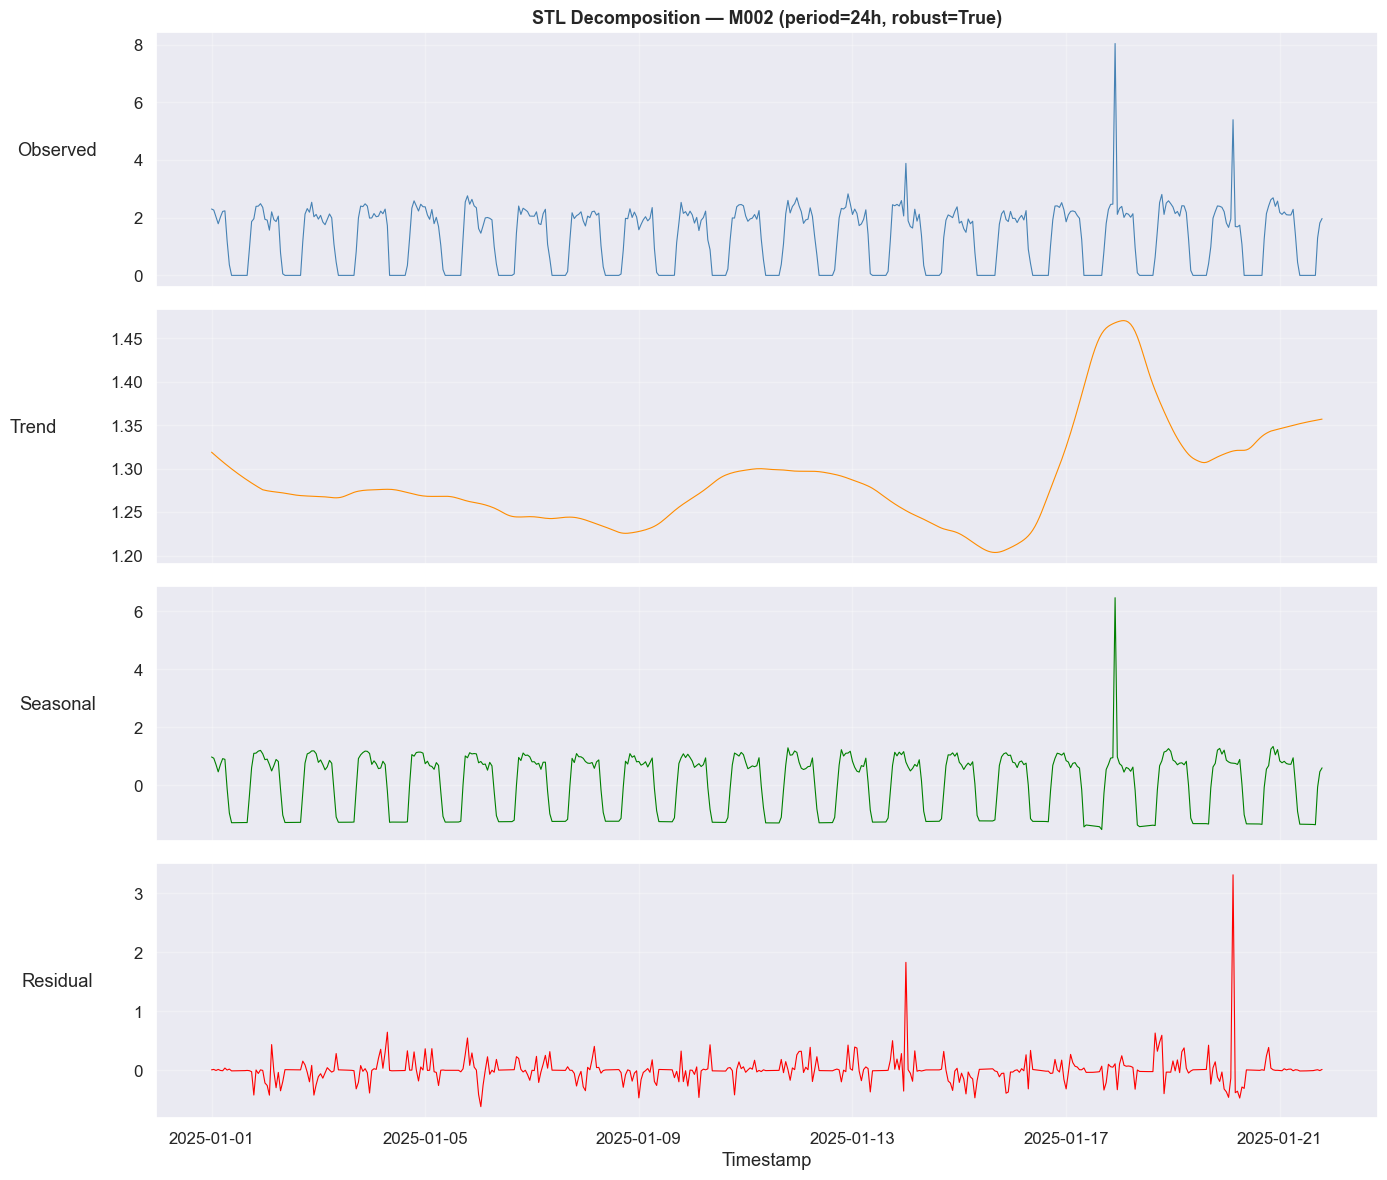

=== Variance decomposition ===

Trend     : 0.3 % of total variance

Seasonal  : 95.4 % of total variance

Residual  : 4.9 % of total variance

In [60]:
stlModel  = STL(consumptionSeries, period=24, robust=True)
stlResult = stlModel.fit()


stlComponents   = {'Observed': consumptionSeries, 'Trend': stlResult.trend,
                   'Seasonal': stlResult.seasonal, 'Residual': stlResult.resid}
componentColors = ['steelblue', 'darkorange', 'green', 'red']


fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, (name, comp), color in zip(axes, stlComponents.items(), componentColors):
    ax.plot(comp.index, comp, lw=0.8, color=color)
    ax.set_ylabel(name, rotation=0, labelpad=55)
    ax.grid(True, alpha=0.3)
axes[0].set_title(f'STL Decomposition — {METER} (period=24h, robust=True)',
                  fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
saveFig('stlDecomposition.png')
plt.show()


totalVar = consumptionSeries.var()
print('=== Variance decomposition ===')
for name, comp in [('Trend', stlResult.trend), ('Seasonal', stlResult.seasonal), ('Residual', stlResult.resid)]:
    print(f'  {name:<10}: {comp.var() / totalVar * 100:.1f} % of total variance')

---
## Task 12 — Stationarise if needed

We test three candidate series and rerun ADF on each so the decision is data driven

=== Stationarity check at each stage ===

Original                                    ADF p=0.0000  →  STATIONARY

First difference (d=1)                      ADF p=0.0000  →  STATIONARY

Seasonal diff d=1, D=1 (period=24)          ADF p=0.0000  →  STATIONARY

STL residuals (detrended + deseasoned)      ADF p=0.0000  →  STATIONARY

Saved → plots\stationarityComparison.png

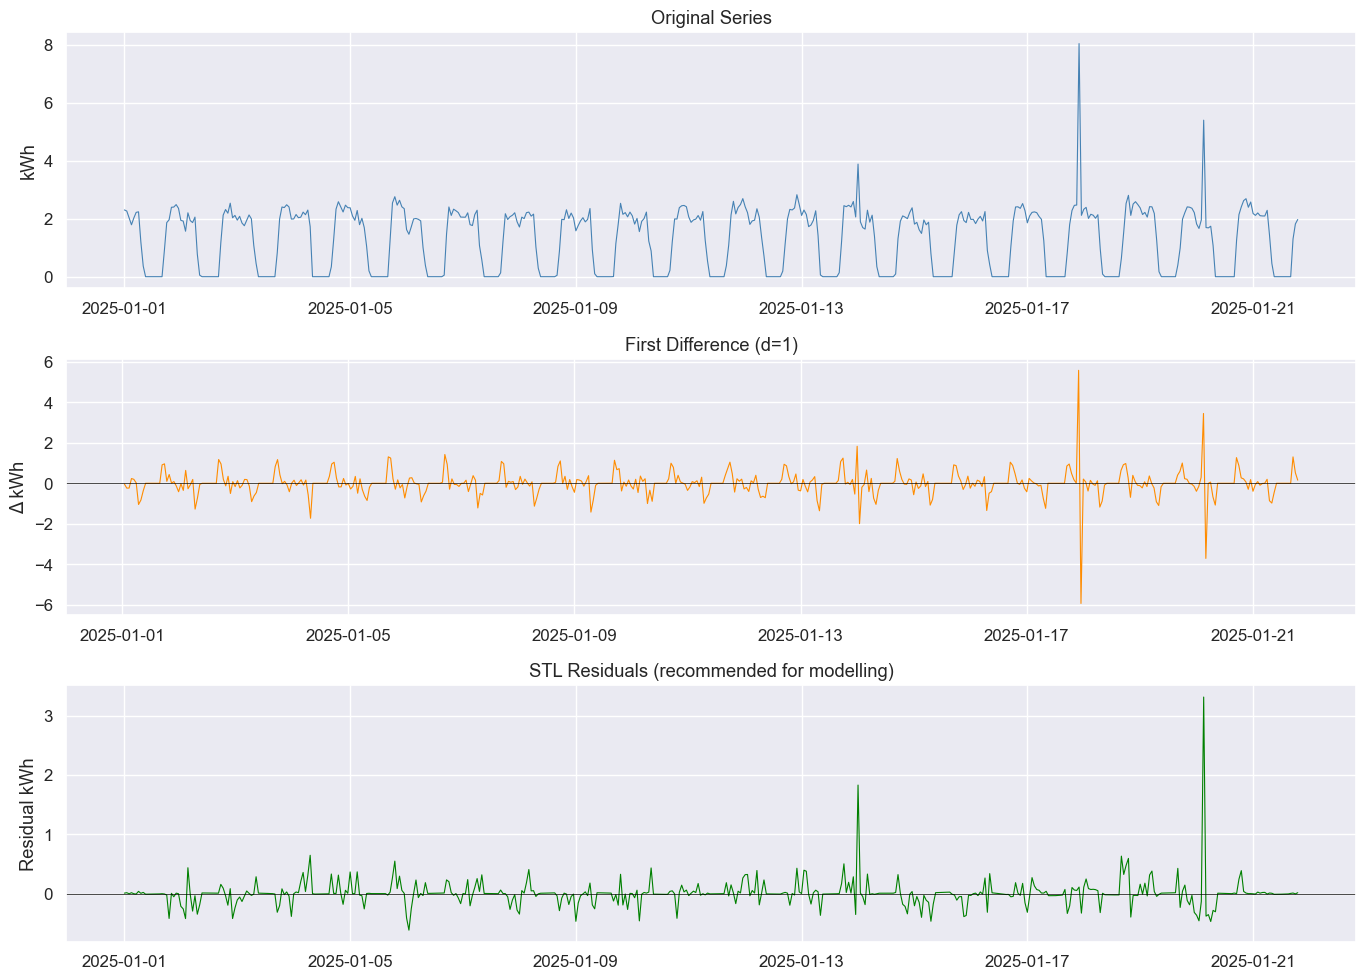

In [61]:
def runAdf(series, label=''):
    r = adfuller(series.dropna(), autolag='AIC')
    verdict = 'STATIONARY' if r[1] < 0.05 else 'NON-STATIONARY'
    print(f'{label:42s}  ADF p={r[1]:.4f}  →  {verdict}')
    return r[1]

print('=== Stationarity check at each stage ===')
runAdf(consumptionSeries,                          'Original')
runAdf(consumptionSeries.diff(1).dropna(),          'First difference (d=1)')
runAdf(consumptionSeries.diff(1).diff(24).dropna(), 'Seasonal diff d=1, D=1 (period=24)')

stlResiduals = pd.Series(stlResult.resid.values, index=consumptionSeries.index).dropna()
runAdf(stlResiduals, 'STL residuals (detrended + deseasoned)')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

axes[0].plot(consumptionSeries.index, consumptionSeries, lw=0.8, color='steelblue')
axes[0].set_title('Original Series'); axes[0].set_ylabel('kWh')

diffSeries = consumptionSeries.diff(1).dropna()
axes[1].plot(diffSeries.index, diffSeries, lw=0.8, color='darkorange')
axes[1].set_title('First Difference (d=1)')
axes[1].axhline(0, color='black', lw=0.5); axes[1].set_ylabel('Δ kWh')

axes[2].plot(stlResiduals.index, stlResiduals, lw=0.8, color='green')
axes[2].set_title('STL Residuals (recommended for modelling)')
axes[2].axhline(0, color='black', lw=0.5); axes[2].set_ylabel('Residual kWh')

plt.tight_layout()
saveFig('stationarityComparison.png')
plt.show()

---
## Bonus — Compare residential vs commercial meter

Commercial meter : M008  (std = 1.312 kWh)

Saved → plots\residentialVsCommercial.png

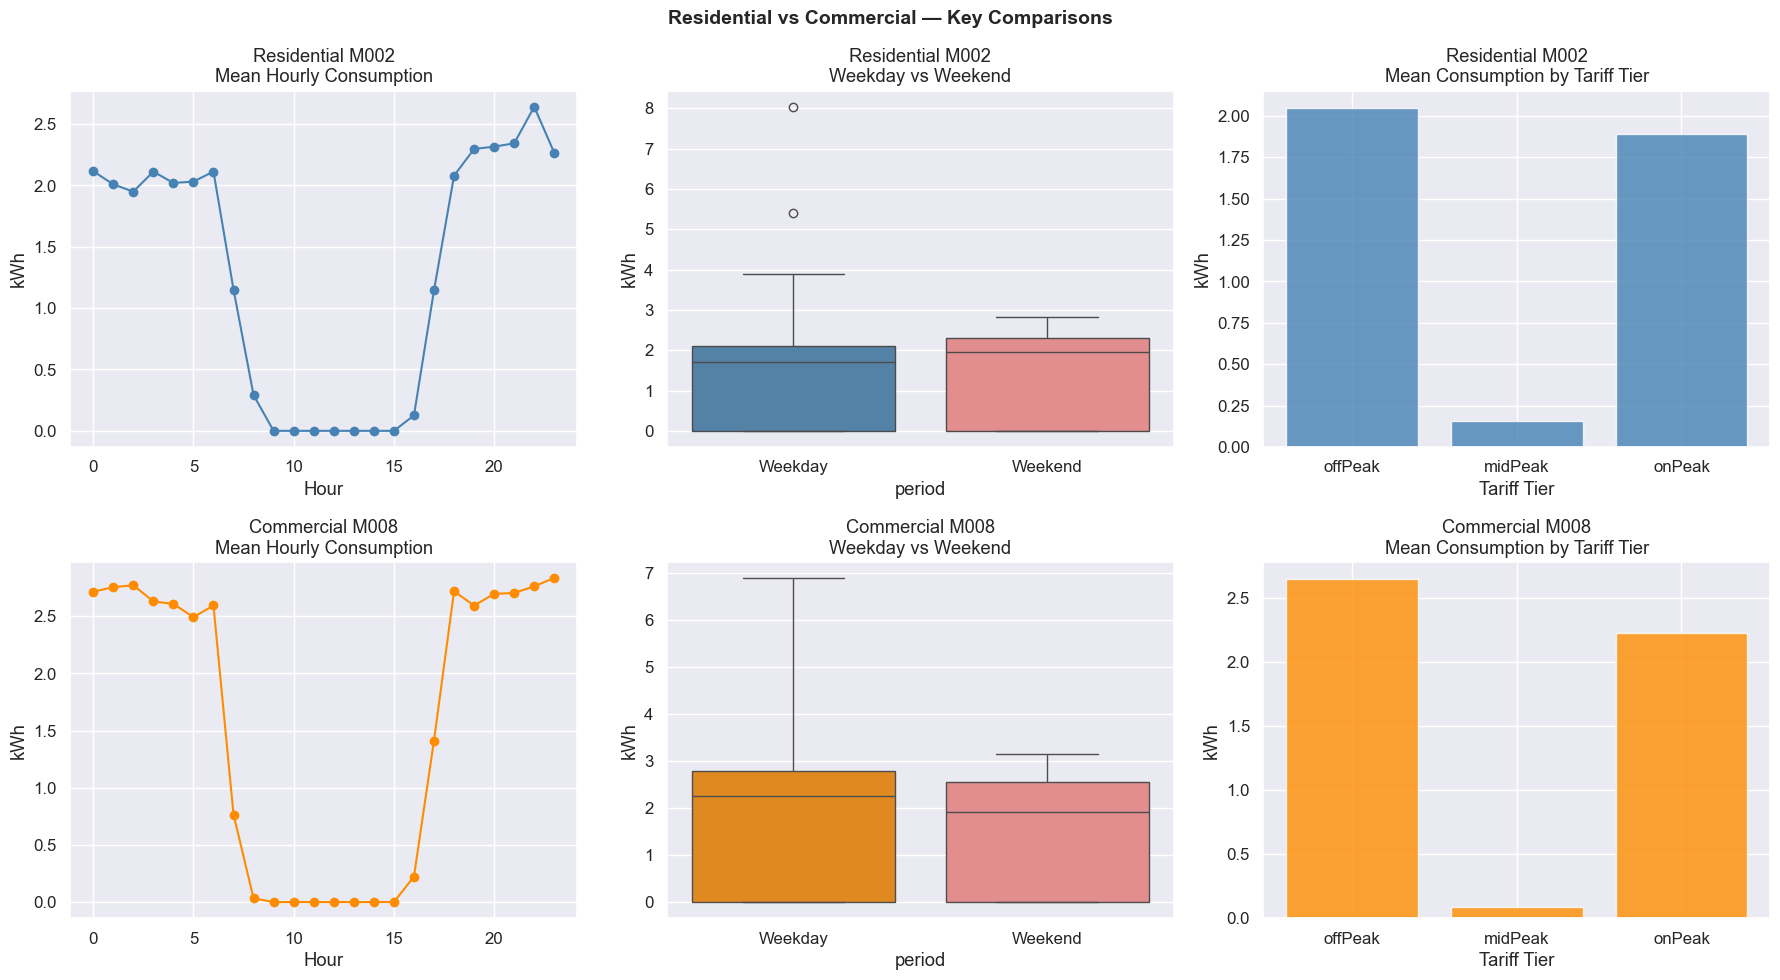

=== Summary Comparison ===

,Mean kWh,Std kWh,CV,Weekend Δ%
Residential M002,1.283,1.073,0.836,7.510
Commercial M008,1.544,1.312,0.850,-11.694


In [62]:
comMeters = (
    masterDf[masterDf['buildingType'] == 'commercial']
    .groupby('meterId')['energyConsumKwh']
    .std()
    .sort_values(ascending=False)
)
METER_COM = comMeters.index[0]
comDf = masterDf[masterDf['meterId'] == METER_COM].copy()
comDf['period'] = comDf['isWeekend'].map({0: 'Weekday', 1: 'Weekend'})
mDf['period']   = mDf['isWeekend'].map({0: 'Weekday', 1: 'Weekend'})

print(f'Commercial meter : {METER_COM}  (std = {comMeters[METER_COM]:.3f} kWh)')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for rowIdx, (meterDf, label, color) in enumerate([
    (mDf,   f'Residential {METER}',    'steelblue'),
    (comDf, f'Commercial {METER_COM}', 'darkorange')
]):
    hourlyProfile = meterDf.groupby('hour')['energyConsumKwh'].mean()
    axes[rowIdx, 0].plot(hourlyProfile.index, hourlyProfile.values, marker='o', color=color, lw=1.5)
    axes[rowIdx, 0].set_title(f'{label}\nMean Hourly Consumption')
    axes[rowIdx, 0].set_xlabel('Hour'); axes[rowIdx, 0].set_ylabel('kWh')

    sns.boxplot(data=meterDf, x='period', y='energyConsumKwh',
                palette=[color, 'lightcoral'], ax=axes[rowIdx, 1])
    axes[rowIdx, 1].set_title(f'{label}\nWeekday vs Weekend')
    axes[rowIdx, 1].set_ylabel('kWh')

    tierMeans = meterDf.groupby('tariffTier')['energyConsumKwh'].mean().reindex(tierOrder)
    axes[rowIdx, 2].bar(tierMeans.index, tierMeans.values, color=color, alpha=0.8)
    axes[rowIdx, 2].set_title(f'{label}\nMean Consumption by Tariff Tier')
    axes[rowIdx, 2].set_xlabel('Tariff Tier'); axes[rowIdx, 2].set_ylabel('kWh')
    axes[rowIdx, 2].tick_params(axis='x')

plt.suptitle('Residential vs Commercial — Key Comparisons', fontsize=14, fontweight='bold')
plt.tight_layout()
saveFig('residentialVsCommercial.png')
plt.show()

summaryDf = pd.DataFrame({
    'Mean kWh'   : [mDf['energyConsumKwh'].mean(),   comDf['energyConsumKwh'].mean()],
    'Std kWh'    : [mDf['energyConsumKwh'].std(),    comDf['energyConsumKwh'].std()],
    'CV'         : [mDf['energyConsumKwh'].std()  / mDf['energyConsumKwh'].mean(),
                    comDf['energyConsumKwh'].std() / comDf['energyConsumKwh'].mean()],
    'Weekend Δ%' : [
        (mDf[mDf.isWeekend == 1]['energyConsumKwh'].mean() /
         mDf[mDf.isWeekend == 0]['energyConsumKwh'].mean() - 1) * 100,
        (comDf[comDf.isWeekend == 1]['energyConsumKwh'].mean() /
         comDf[comDf.isWeekend == 0]['energyConsumKwh'].mean() - 1) * 100
    ]
}, index=[f'Residential {METER}', f'Commercial {METER_COM}'])

print('\n=== Summary Comparison ===')
display(summaryDf.round(3))